<a href="https://colab.research.google.com/github/alex-smith-uwec/CS491/blob/main/PromptsTop2Vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
my_path="/content/drive/MyDrive/CS491NLP/Data/"

# Load dataset from Hugging Face 🤗

In [3]:
!pip install datasets -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.6 MB/s eta 0:00:00


In [4]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("DIBT/10k_prompts_ranked")

docs = dataset['train']['prompt']

##get a summary of dataset
dataset

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/10331 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['prompt', 'quality', 'metadata', 'avg_rating', 'num_responses', 'agreement_ratio', 'raw_responses', 'kind', 'cluster_description', 'topic'],
        num_rows: 10331
    })
})

In [5]:
import random
print(f'number of prompts in dataset: {len(docs)}\n')
r=random.randint(0, len(docs)-1)
print(f'A random entry:\n {docs[r]}')

number of prompts in dataset: 10331

A random entry:
 Web search results:

[1] "Minimally, a textbook is a summary of a field of psychology, but it generally is a lot more because it involves synthesis, analysis, critique, and a venue for a fresh perspective and novel ideas. Psychology textbooks are often the first resource professors look to find a reference or to learn about a concept or particular study."
URL: https://www.psychologicalscience.org/observer/writing-a-psychology-textbook

[2] "Principles on psychological report writing derived from seminal papers in the field of psychological assessment were adapted and used as an organizing tool to create a template on how to write all varieties of psychological reports that incorporate evidence-based assessment methods. ... Content may require purchase if you do not have access ..."
URL: https://www.cambridge.org/core/books/cambridge-handbook-of-clinical-assessment-and-diagnosis/writing-a-psychological-report-using-evidencebased-psyc

# Train Top2Vec model. Also save and load.

In [6]:
!pip install top2vec -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 9.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 7.4 MB/s eta 0:00:00


If you have arleady trained a model and saved it, then you can load it with the following prompt and skip the training.

❌
 **Of course the first time through you should skip the next command!**

In [7]:
# Load model
import pickle

with open(my_path+'prompt_deep_model.pkl', 'rb') as f:
    model = pickle.load(f)

The next cell is the work horse, where the model is trained. ⛽: ⏰ It might take some time, so be patient.

In [8]:
##If model is already trained and saved (see section below) then this can be skipped!!
from top2vec import Top2Vec

# Assuming 'docs' is a list of text documents you wish to model
model = Top2Vec(docs, embedding_model='doc2vec', speed='deep-learn')
#fast-learn, learn, deep-learn


2024-04-01 02:35:44,181 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training
2024-04-01 02:35:49,126 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2024-04-01 02:51:51,965 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2024-04-01 02:52:31,222 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2024-04-01 02:52:31,857 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics


After waiting for the model to be trained, you might consider saving it so that next time you don't have to retrain if you come back to this later! 👍 This is what the next cell does.

In [9]:
import pickle

# Save model
with open(my_path+'prompt_deep_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Proceed with topic analysis after retrieving model

In [10]:
model.get_num_topics()

138

In [11]:
model.get_topic_sizes()

(array([238, 238, 151, 134, 130, 128, 121, 119, 118, 117, 116, 115, 113,
        112, 111, 109, 103, 103,  99,  99,  99,  99,  99,  95,  95,  94,
         93,  93,  92,  91,  91,  87,  87,  86,  86,  84,  83,  83,  82,
         82,  81,  80,  80,  80,  79,  79,  79,  78,  77,  77,  77,  76,
         76,  75,  75,  75,  75,  75,  74,  73,  73,  73,  72,  72,  72,
         71,  71,  70,  70,  69,  69,  69,  68,  67,  67,  67,  67,  67,
         66,  66,  65,  65,  65,  65,  65,  65,  64,  63,  63,  63,  63,
         62,  62,  61,  60,  60,  60,  60,  60,  58,  58,  58,  57,  57,
         56,  56,  56,  56,  55,  55,  54,  54,  53,  52,  51,  51,  49,
         49,  48,  47,  46,  46,  45,  45,  45,  44,  44,  41,  41,  41,
         40,  39,  35,  33,  33,  31,  30,  29]),
 array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
 

**Question: What do the integers in the first array mean**: ⭕

---



Your Answer:
The integers in the first array means the sizes of the topics generated by the Top2Vec model.


In [12]:
model.topic_words[0:3]

array([['impact', 'climate', 'implications', 'environmental', 'economic',
        'potential', 'analysis', 'effects', 'factors', 'research',
        'findings', 'sources', 'examine', 'policy', 'provide',
        'effectiveness', 'discuss', 'ethical', 'individuals', 'policies',
        'solutions', 'opportunities', 'consider', 'additionally',
        'cultural', 'trends', 'efforts', 'recommendations', 'scientific',
        'promote', 'support', 'influence', 'challenges', 'consumption',
        'strategies', 'including', 'industry', 'importance',
        'sustainable', 'practices', 'explore', 'such', 'advantages',
        'examples', 'various', 'evidence', 'growth', 'organizations',
        'technologies', 'social'],
       ['method', 'class', 'specifications', 'implementation',
        'instance', 'implement', 'constructor', 'returns', 'task',
        'complete', 'parameter', 'object', 'parameters', 'missing',
        'attribute', 'snippet', 'takes', 'boolean', 'assume', 'methods',
    

# Documents similar to keywords

##Pick some keywords that look interesting in the top 3-4 topics:

*   model.topic_words[0]
*   model.topic_words[1]
*   model.topic_words[2]
*   etc.

In [13]:
# Assuming 'model' is your trained Top2Vec model and 'keywords' is a list of keywords.
keywords = ["function","integer"]
documents, document_score, document_ids = model.search_documents_by_keywords(keywords=keywords, num_docs=5)

# This will return the top most similar documents to the provided keywords,
# their similarity scores, and their IDs within the model.


In [14]:
# Print the results
for i in range(len(documents)):
    print(f"Document ID: {document_ids[i]}")
    print(f"Similarity Score: {document_score[i]}")
    print(f"Document Content: {documents[i][:200]}...")  # Print the first 200 characters to get an idea of the document content
    print("---")

Document ID: 9628
Similarity Score: 0.2980785071849823
Document Content: You are given a code snippet that aims to display the sum of two variables, one of type `int` and the other of type `float`. Your task is to complete the code by writing the necessary statements to pe...
---
Document ID: 1398
Similarity Score: 0.2952479124069214
Document Content: You are given a code snippet that calculates a percentage based on a given 2D array and a tolerance value. Your task is to write a function that completes the code snippet by implementing the missing ...
---
Document ID: 5253
Similarity Score: 0.2791471481323242
Document Content: You are given a code snippet that involves converting the coordinates of a 3D vector (`fv`) from floating-point (`float32`) to unsigned 32-bit integers (`uint32`). Your task is to write a function tha...
---
Document ID: 3087
Similarity Score: 0.2765122652053833
Document Content: You are given a code snippet containing an incomplete function. Your task is to comp

# Topic modeling

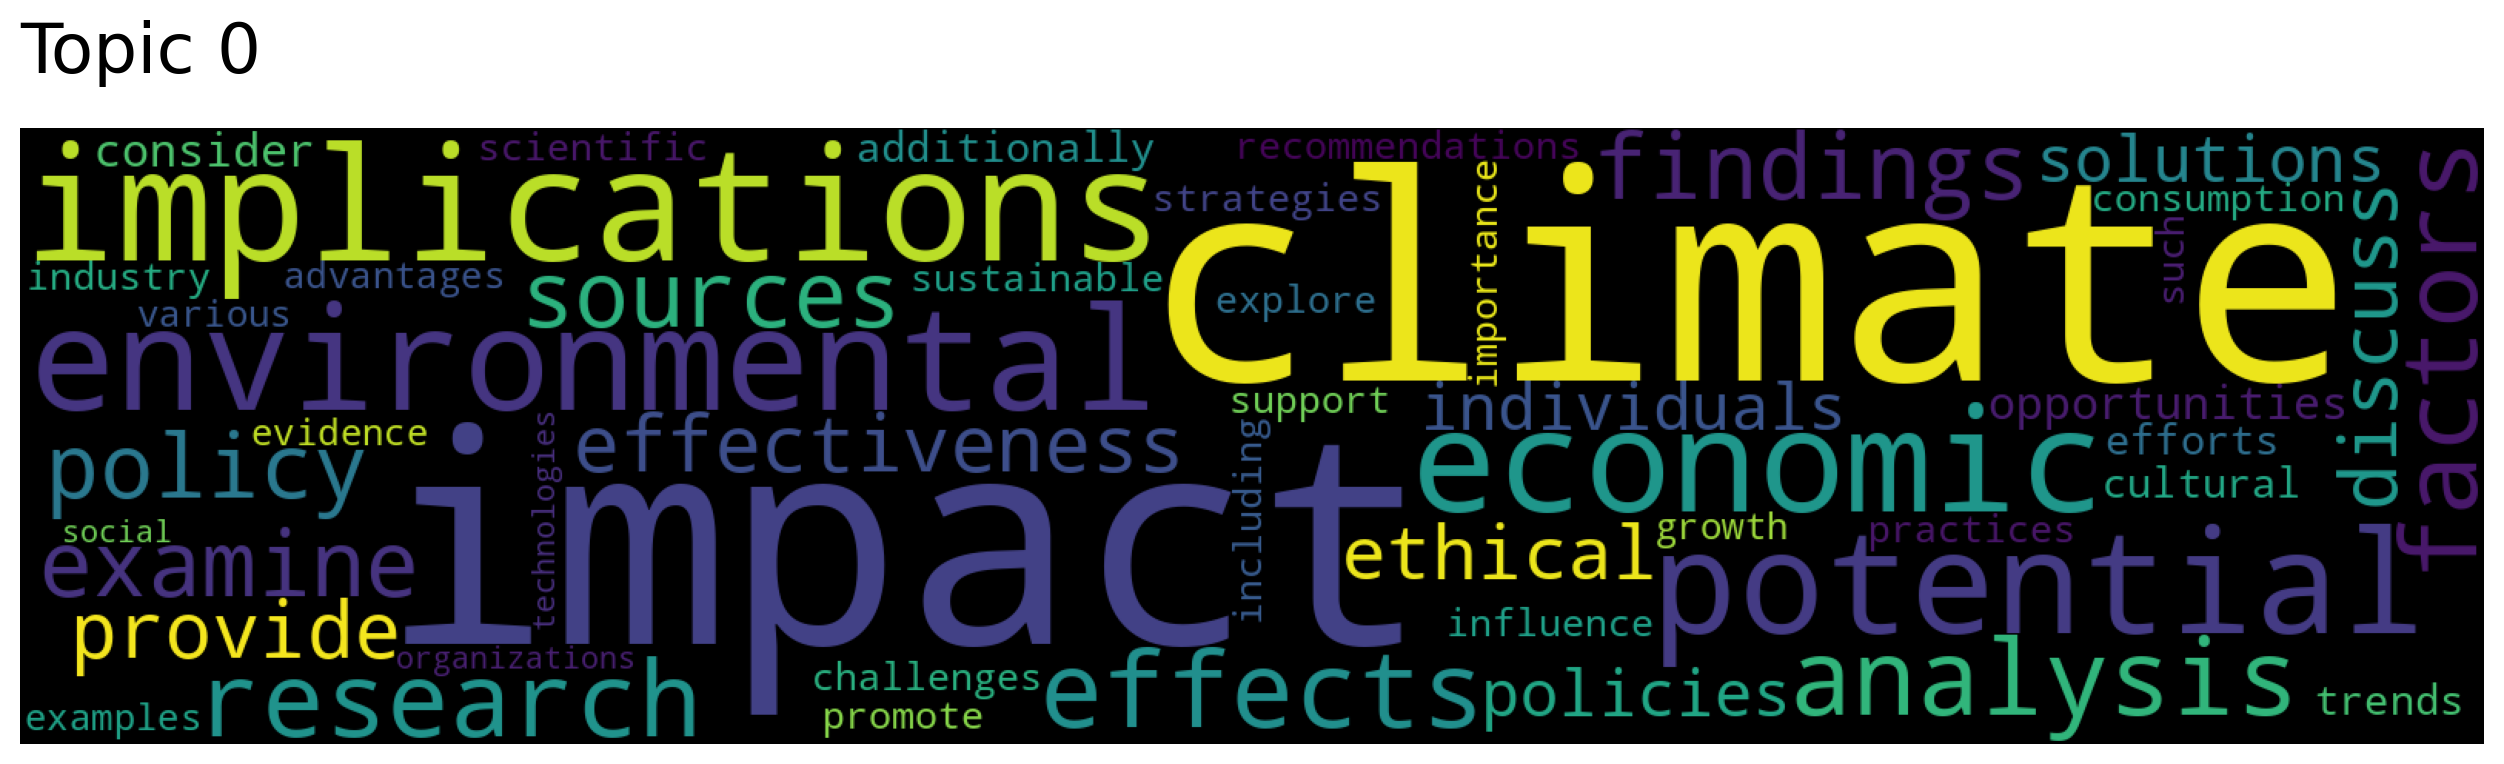

In [15]:
model.generate_topic_wordcloud(0)

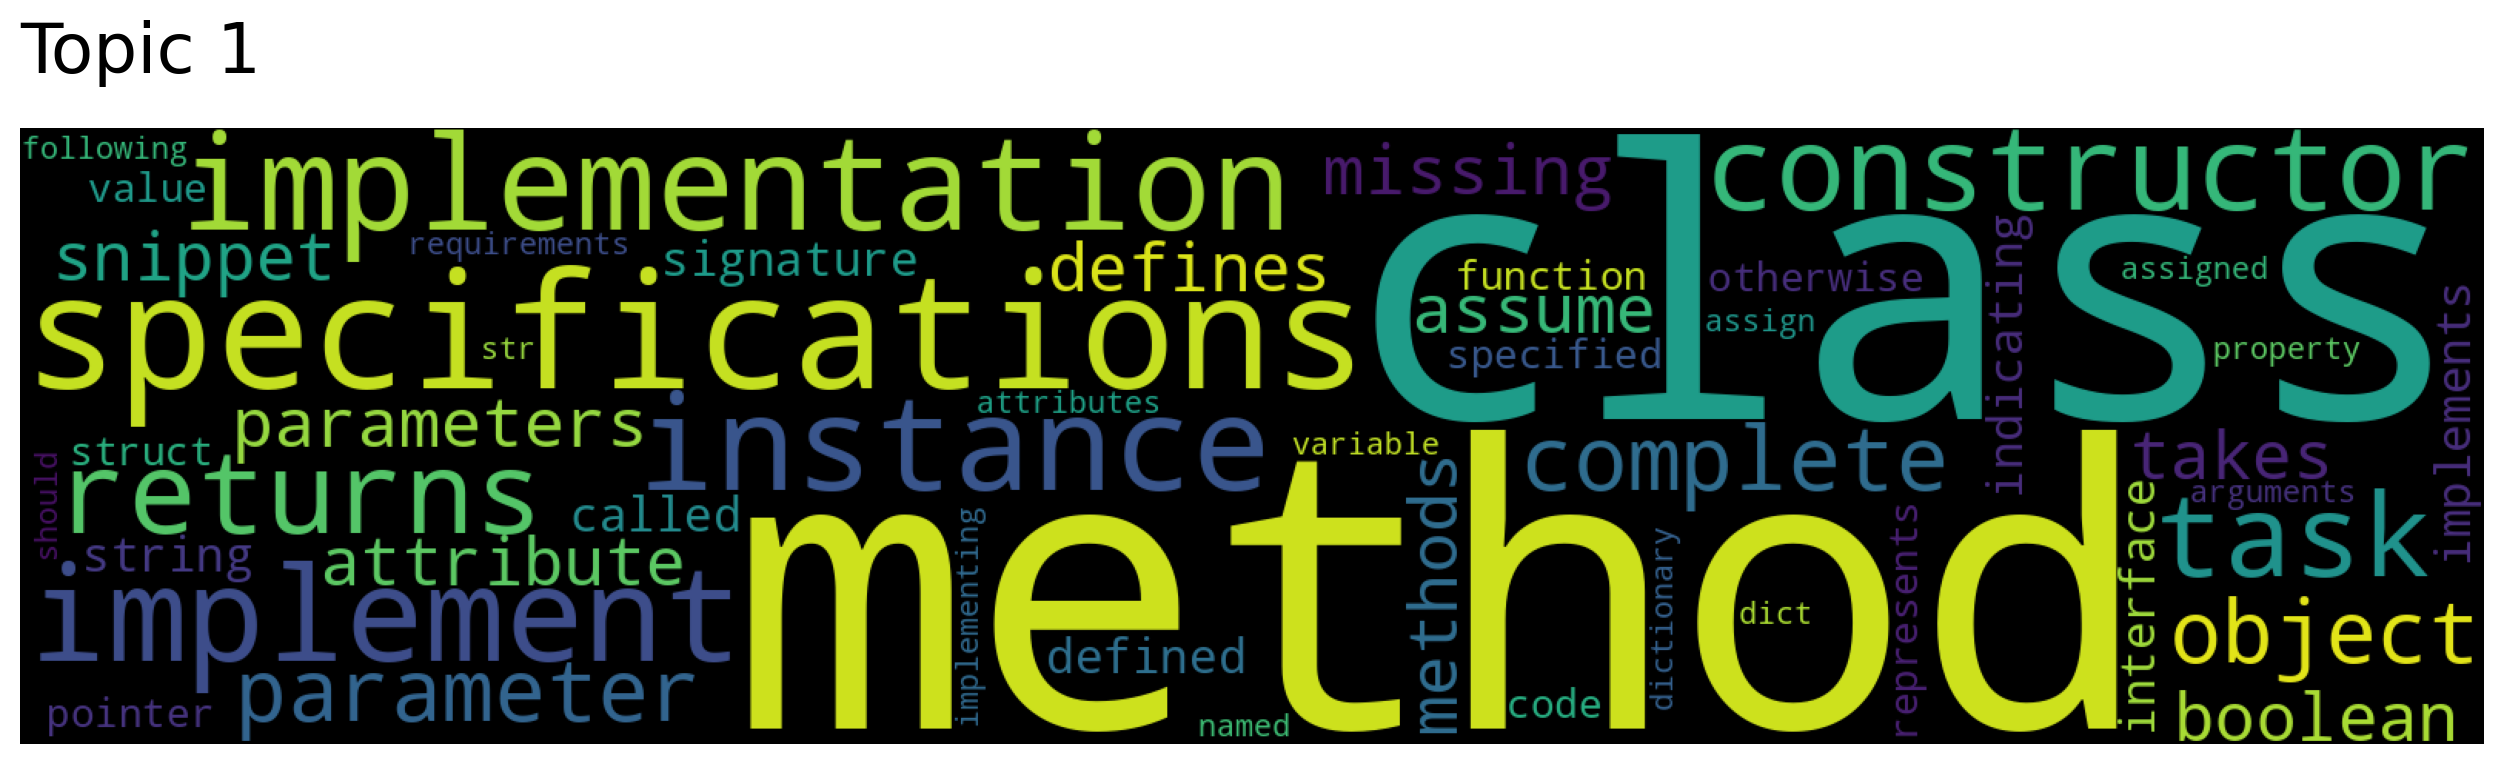

In [16]:
model.generate_topic_wordcloud(1)

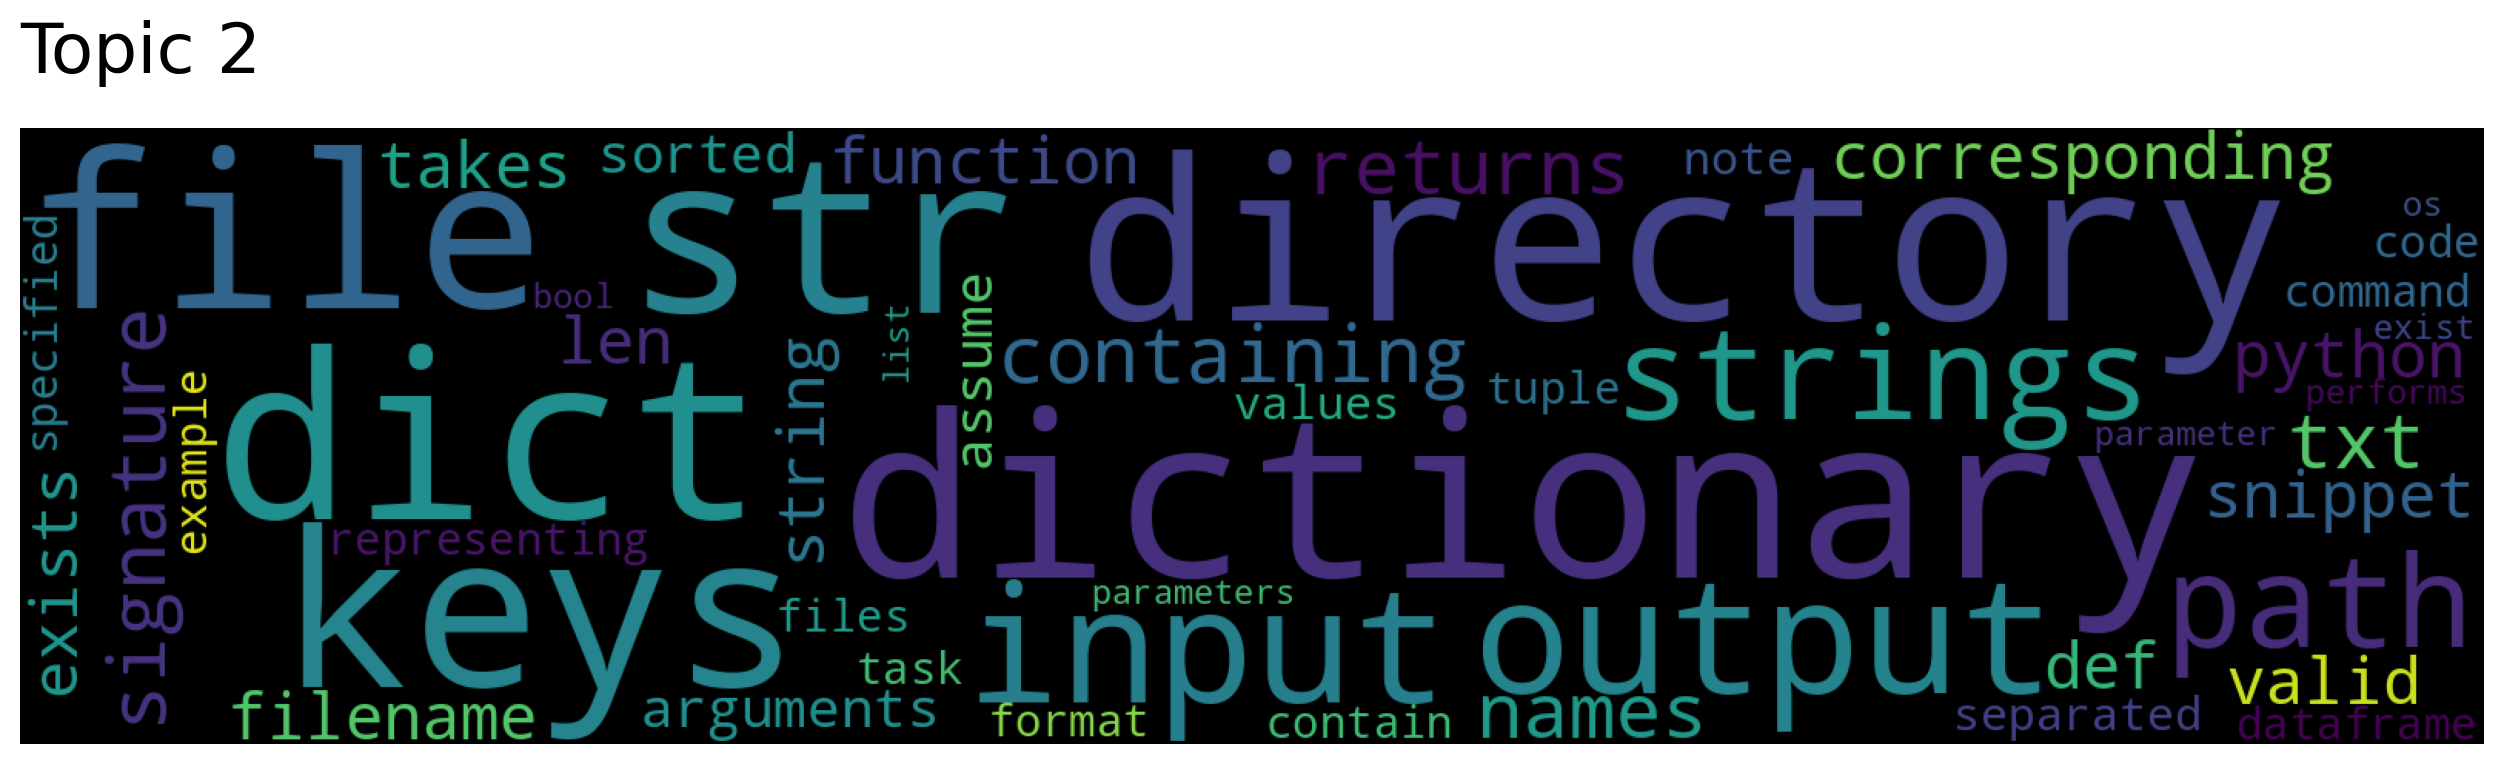

In [17]:
model.generate_topic_wordcloud(2)

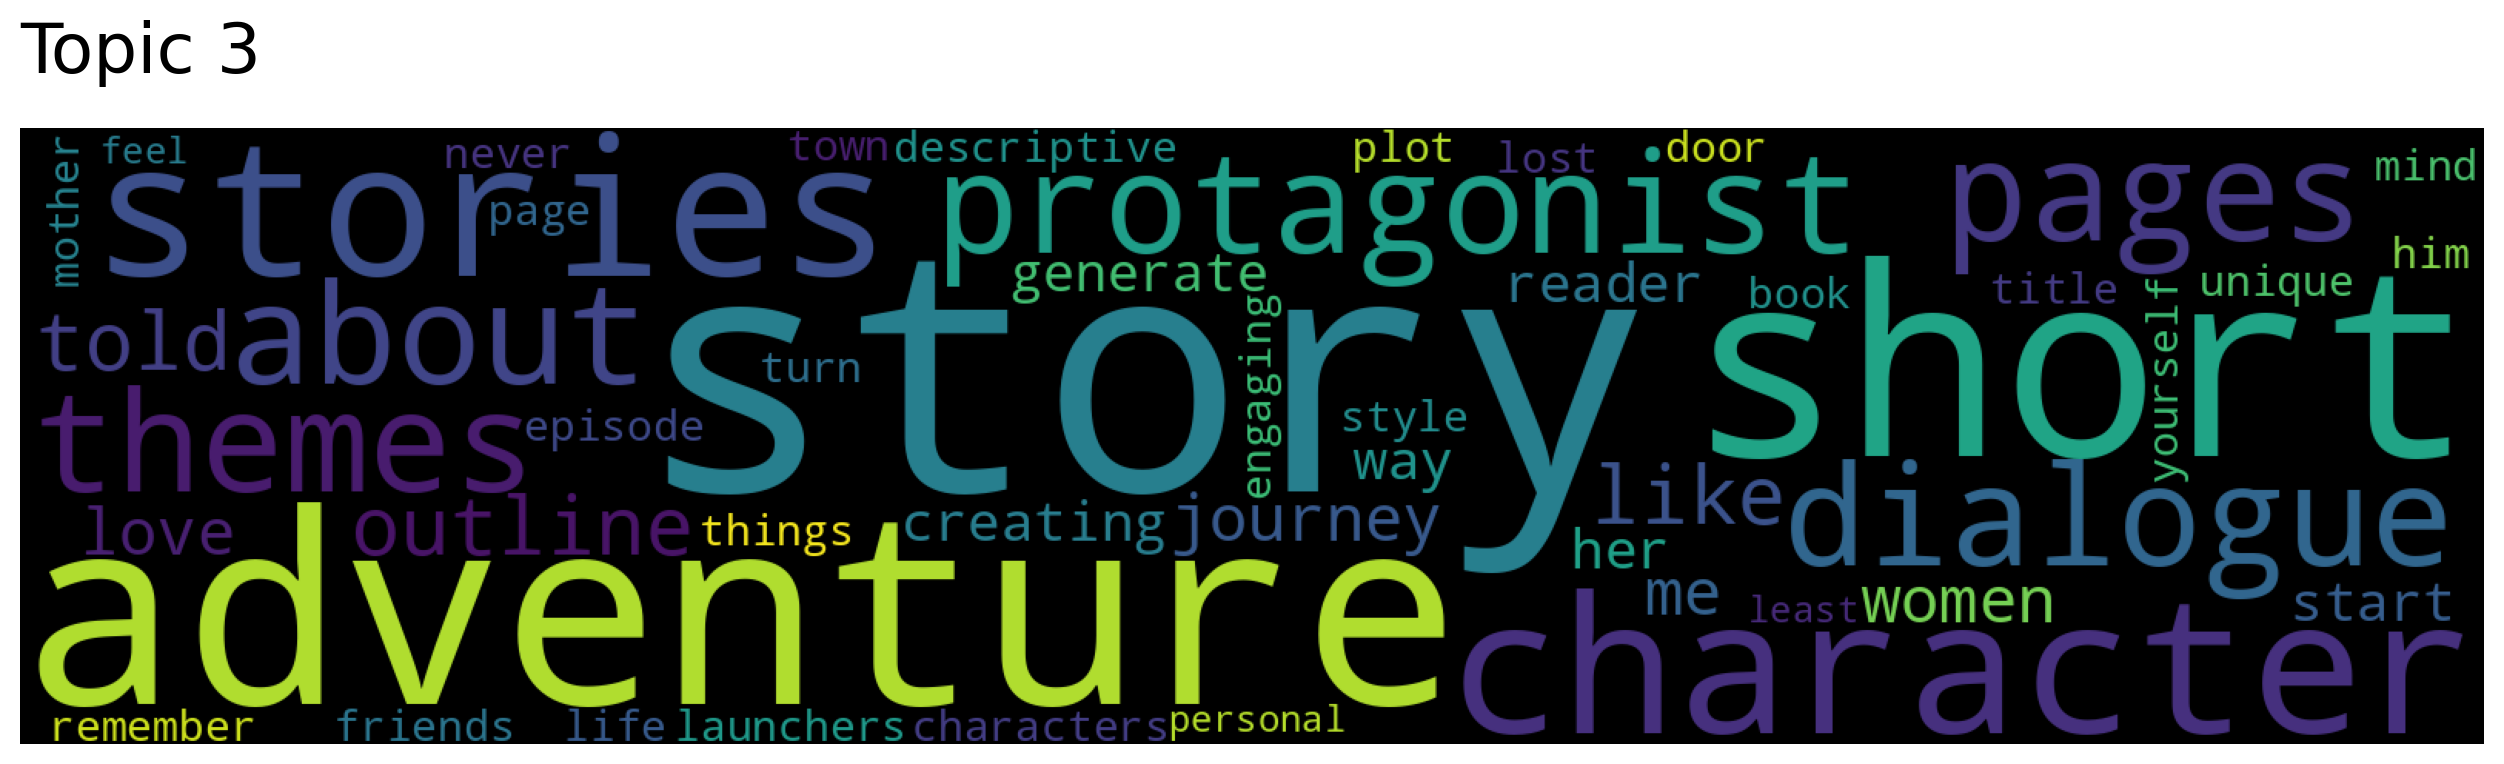

In [18]:
model.generate_topic_wordcloud(3)

Look at documents aligning with a topic

In [19]:
model.search_documents_by_topic(topic_num=0, num_docs=5)

(array(['Write a research paper that thoroughly analyzes the current and predicted effects of climate change on a specific ecosystem or group of ecosystems worldwide. Additionally, suggest potential solutions, policies, or actions that entities like governments or individuals can take to mitigate the impact of climate change on the selected ecosystem(s). In your analysis, consider both the ecological and socio-economic implications of the suggested solutions. Use credible sources to support your arguments and provide specific examples demonstrating the impact and effectiveness of the potential solutions proposed.',
        'Conduct a detailed case study on the biological, economic, and social impact of the rise in temperature levels caused by climate change on grape varieties used in wine production. Specifically, analyze the changes in grape yield, quality, and taste, as well as the adaptations made by farmers and winemakers to mitigate the effects of climate change. Provide examples 

Using the wordclouds, model.search_documents_by_topic, model.topic_words

**Give a 2-4 word summary for each of the the top four topics** ⭕

Your answers here:
Topic0: 'impact', 'climate', 'implications', 'environmental';
Topic1: 'method', 'class', 'specifications', 'implementation';
Topic2: 'dict', 'dictionary', 'directory', 'str';
Topic3: 'story', 'adventure', 'short'.
